### Telco Customer Churn 

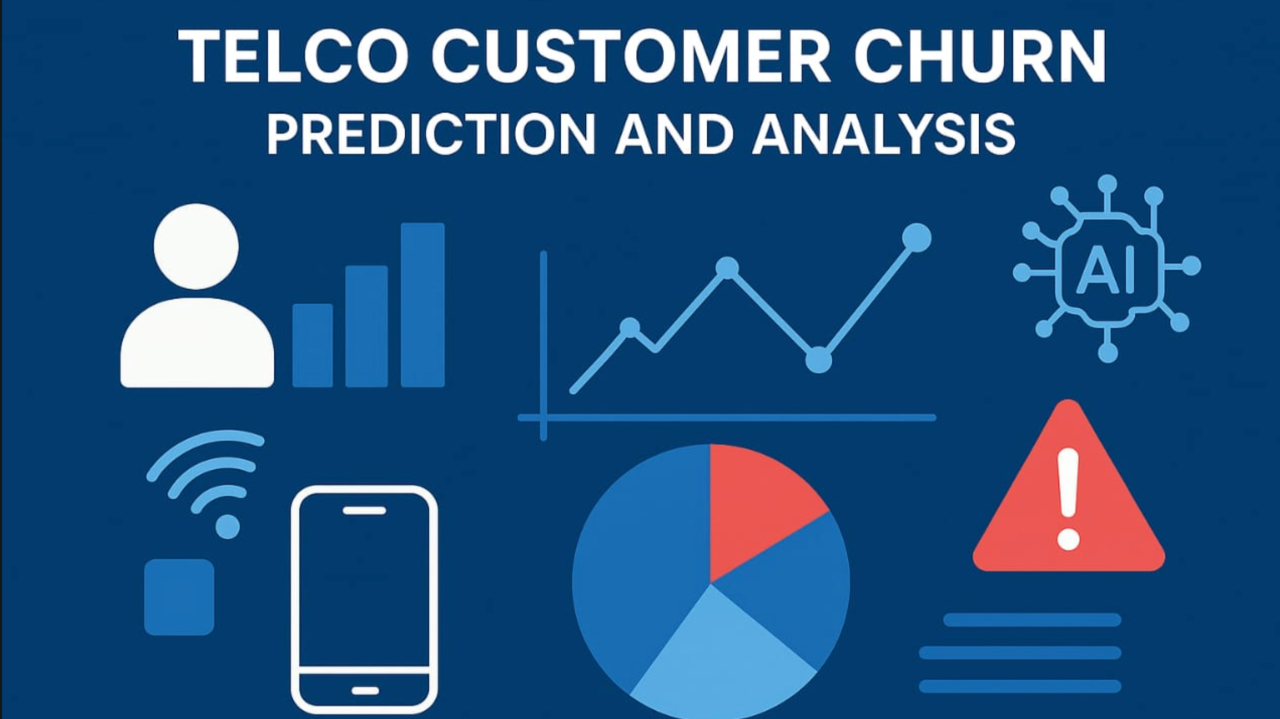

### Problem Statement
The objective is to analyze customer data from a telecom company and build a predictive model to identify customers who are likely to churn (i.e., stop using the service). By predicting churn, the company can take proactive measures to improve customer retention.

#### Dataset Information

- Rows (Records): 7,043
- Columns (Features): 21
- Missing Values: 0 (no null values detected)

#### Column Details

- Customer ID: customerID (unique identifier)
- Demographics: gender, SeniorCitizen, Partner, Dependents
- Customer Info: tenure (months), PhoneService, MultipleLines, InternetService
- Services: OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- Account Info: Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges
- Target Variable: Churn (Yes/No → whether customer left or not)

#### Data Types

- Categorical (Object): 18 columns (e.g., Gender, InternetService, Churn)
- Numeric (Int64): 2 columns (SeniorCitizen, tenure)
- Numeric (Float64): 1 column (MonthlyCharges, TotalCharges – though TotalCharges is read as string sometimes)

### Variables in the Telco Customer Churn Dataset

#### Dependent Variable (Target)
- **Churn** → (Yes/No)  
  Indicates whether a customer has left the company.

#### Independent Variables (Features)

#### Demographic Information
- `gender` (Male/Female)  
- `SeniorCitizen` (0 = No, 1 = Yes)  
- `Partner` (Yes/No)  
- `Dependents` (Yes/No)  

#### Customer Account / Services
- `tenure` (Number of months the customer has stayed)  
- `PhoneService` (Yes/No)  
- `MultipleLines` (Yes/No/No phone service)  
- `InternetService` (DSL/Fiber optic/No)  
- `OnlineSecurity` (Yes/No/No internet service)  
- `OnlineBackup` (Yes/No/No internet service)  
- `DeviceProtection` (Yes/No/No internet service)  
- `TechSupport` (Yes/No/No internet service)  
- `StreamingTV` (Yes/No/No internet service)  
- `StreamingMovies` (Yes/No/No internet service)  

#### Contract & Payment Information
- `Contract` (Month-to-month/One year/Two year)  
- `PaperlessBilling` (Yes/No)  
- `PaymentMethod` (Electronic check, Mailed check, Bank transfer, Credit card)  
- `MonthlyCharges` (Numeric – customer’s monthly bill)  
- `TotalCharges` (Numeric – total amount charged)  

#### Identifier (Not used for modeling)
- `customerID` (Unique ID → drop before training)  

**Summary:**  
- **Independent Variables:** 19 (after removing `customerID`)  
- **Dependent Variable:** 1 (`Churn`)  

In [1]:
# Importing neccessary packages
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
# ignore warning
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mtick # for showing percentage in it

In [3]:
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.dtypes # datatype

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

From analyst the data set we noticed that some of the independence features are in mumerical and most of features are in categorical fatures seperate into numerical and categorical data for the EDa parts.

In [5]:
# Total charges are in obeject dtype so convert into numerical features
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Insights:-

- **Rows & Columns**: Dataset has 7043 rows × 21 columns.  
- **Data Types**:
### **Numerical**:  
- **SeniorCitizen** (int64, binary: 0/1)  
- **tenure** (int64, months)  
- **MonthlyCharges, TotalCharges** (float64)  
- **Categorical (object)**: 17 columns like gender, Partner, Dependents, InternetService, Contract, PaymentMethod, etc.  
- **Conversion**: TotalCharges was originally object, now converted to float64.  
- **Missing Values**: TotalCharges has 7032 non-null vs 7043 rows → 11 missing values.  
- **Memory Usage**: ~1.1 MB, dataset is small & manageable.  

Data needs **encoding** (for categorical variables) + handling of missing values before ML modeling.

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Insights:-

- **SeniorCitizen**: Only ~16% are senior citizens (mostly 0 → non-seniors).  
- **Tenure**: Customers range from new (0 months) to 72 months (6 years).  
  - Median = 29 months → half of customers stay < 2.5 years.  
- **MonthlyCharges**: Range from $18.25 to $118.75.  
  - Median = $70.35 → most customers pay around $70/month.  
- **TotalCharges**: Range from $18.8 to $8684.8.  
  - Median = $1397 → half of customers pay less than ~$1400 overall.  
- **Std Dev**: High variability in Monthly & Total Charges → diverse customer billing patterns.  
- **Missing Values**: TotalCharges has 7032 vs 7043 count → 11 missing values.  


In [8]:
df.shape

(7043, 21)

### Seperate into Categorical & Numerical Features

In [9]:
# numerical feature
numerical_feature = {feature for feature in df.columns if df[feature].dtypes != 'O'}
print(f'Count of Numerical feature: {len(numerical_feature)}')
print(f'Numerical feature are:\n {numerical_feature}')

Count of Numerical feature: 4
Numerical feature are:
 {'tenure', 'TotalCharges', 'MonthlyCharges', 'SeniorCitizen'}


In [19]:
# Categorical feature
categorical_feature = {feature for feature in df.columns if df[feature].dtypes == 'O'}
print(f'Count of Categorical feature: {len(categorical_feature)}')
print(f'Categorical feature are:\n {categorical_feature}')

Count of Categorical feature: 17
Categorical feature are:
 {'Churn', 'PaymentMethod', 'PaperlessBilling', 'Contract', 'DeviceProtection', 'gender', 'customerID', 'MultipleLines', 'TechSupport', 'OnlineBackup', 'StreamingMovies', 'Partner', 'StreamingTV', 'PhoneService', 'OnlineSecurity', 'Dependents', 'InternetService'}


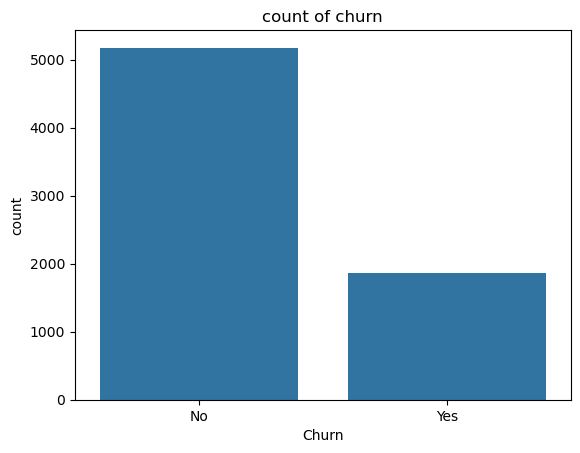

In [11]:
# Ploting with target features
sns.countplot(data=df,x="Churn")
plt.title("count of churn")
plt.show()

### Insights from Churn Distribution
- **Churn = No**: Majority of customers (~5200).  
- **Churn = Yes**: Minority (~1800).  
- **Class Imbalance**: Dataset is **imbalanced** → churners are much fewer than non-churners.  
- **Impact**:  
  - Important to handle imbalance (SMOTE, class weights, undersampling, etc.) for ML models.  
  - If ignored, models may be biased toward predicting "No churn".

In [12]:
per=df.loc[df["Churn"]=="Yes"].count()[0]
print(f"percentage of left:{per/len(df["Churn"])}")
print(df.Churn.value_counts())

percentage of left:0.2653698707936959
Churn
No     5174
Yes    1869
Name: count, dtype: int64


INSIGHTS:-

1869 of costomer are left about 26.5% from overall, this like an imbalance dataset

In [13]:
# How many Loss in Customer Churn
loss=[]
for values in df.loc[df["Churn"]=="Yes","TotalCharges"]:
    value=float(values)
    loss.append(value)

print(np.round(sum(loss)))

2862927.0


INSIGHTS:-

WE have lost around $2862927 due to customer churn.

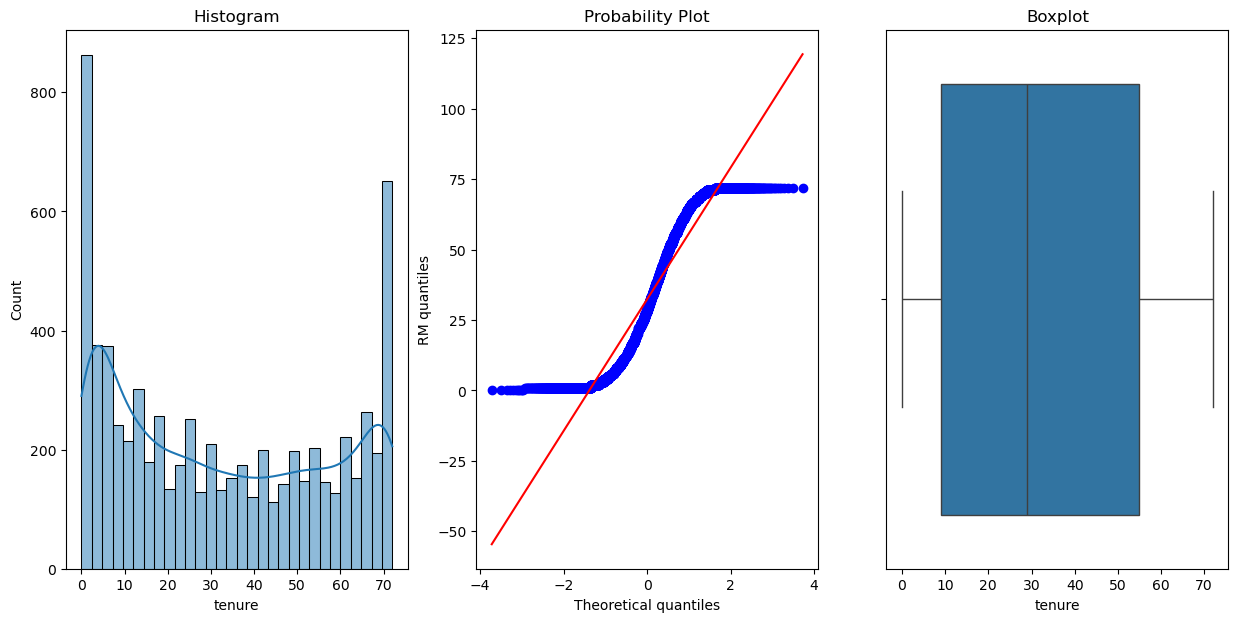

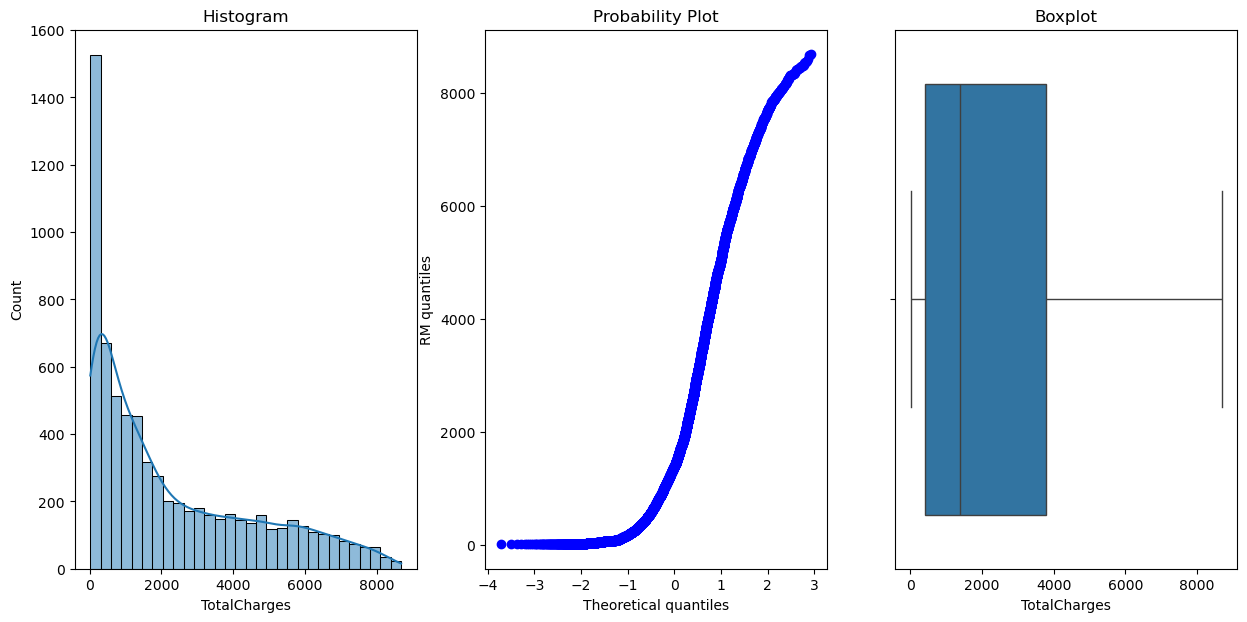

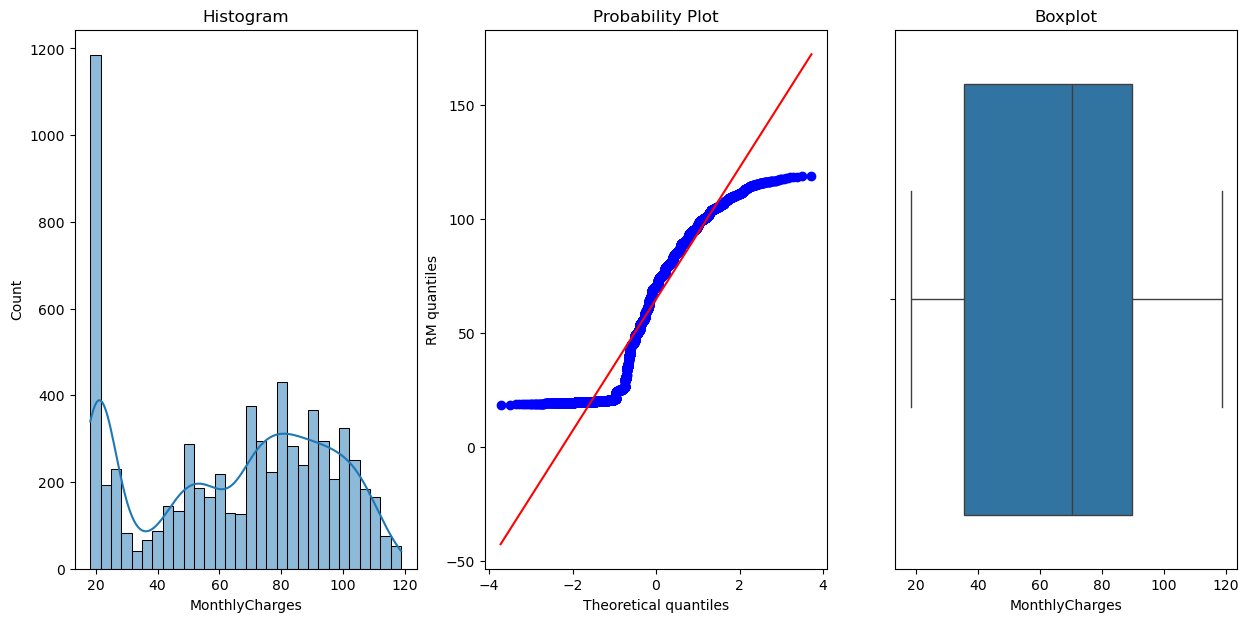

In [14]:
### Plotting numerical feature with probability distribution and checking outlier
for feature in numerical_feature:
    if feature != 'SeniorCitizen':
        plt.figure(figsize=(15,7))
    
        plt.subplot(1, 3, 1)
        sns.histplot(data=df, x=feature, bins=30, kde=True)
        plt.title('Histogram')
    
        plt.subplot(1, 3, 2)
        stats.probplot(df[feature], dist="norm", plot=plt)
        plt.ylabel('RM quantiles')
    
        plt.subplot(1, 3, 3)
        sns.boxplot(x=df[feature])
        plt.title('Boxplot')
    
plt.show()

### INSIGHTS:-

After ploting Histogram, Probability, Boxplotto find numerical value are normally distribution and dataset has no outlier. so we did not want to remove outlier a dataset.

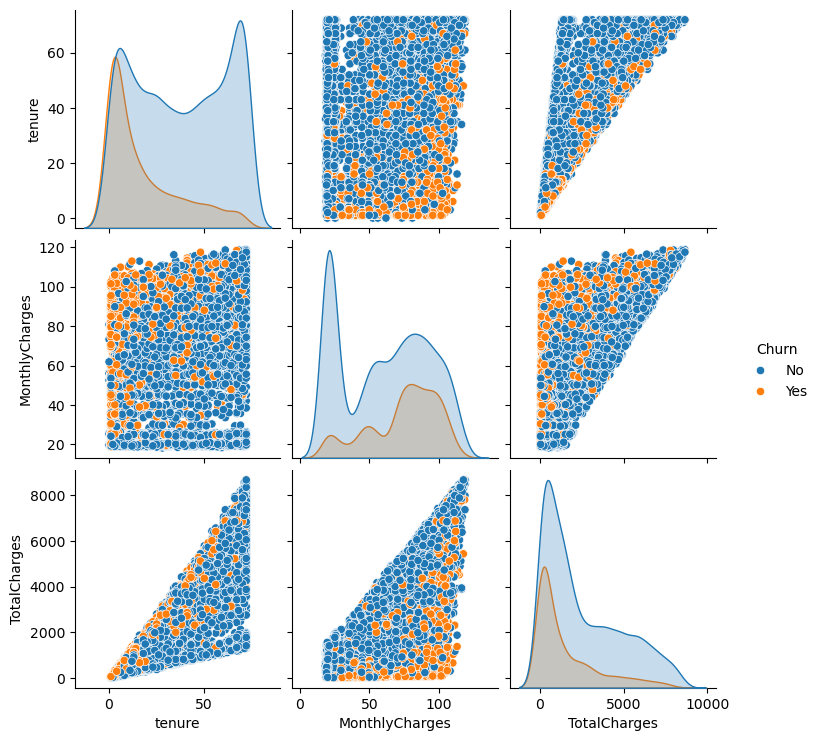

In [15]:
sns.pairplot(df.drop(columns="SeniorCitizen"),hue="Churn",kind="scatter")
plt.show()

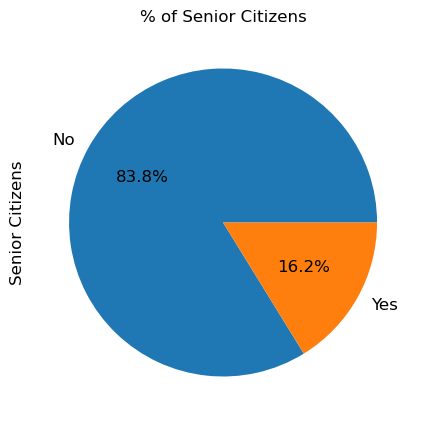

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Pie chart for Count of Senior Citizens
ax = (df['SeniorCitizen'].value_counts() * 100.0 / len(df)).plot.pie(
    autopct='%.1f%%',
    labels=['No', 'Yes'],
    figsize=(5, 5),
    fontsize=12
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Senior Citizens', fontsize=12)
ax.set_title('% of Senior Citizens', fontsize=12)

plt.show()


### INSIGHTS:_

Only 16.2% customers who are senior citizens but remainning 83.8% customer are young people.

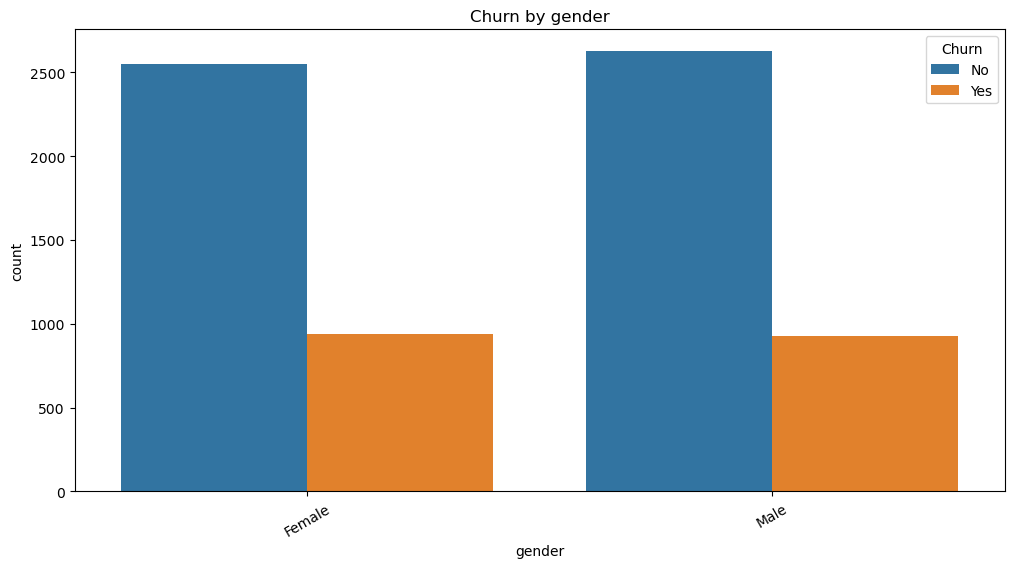

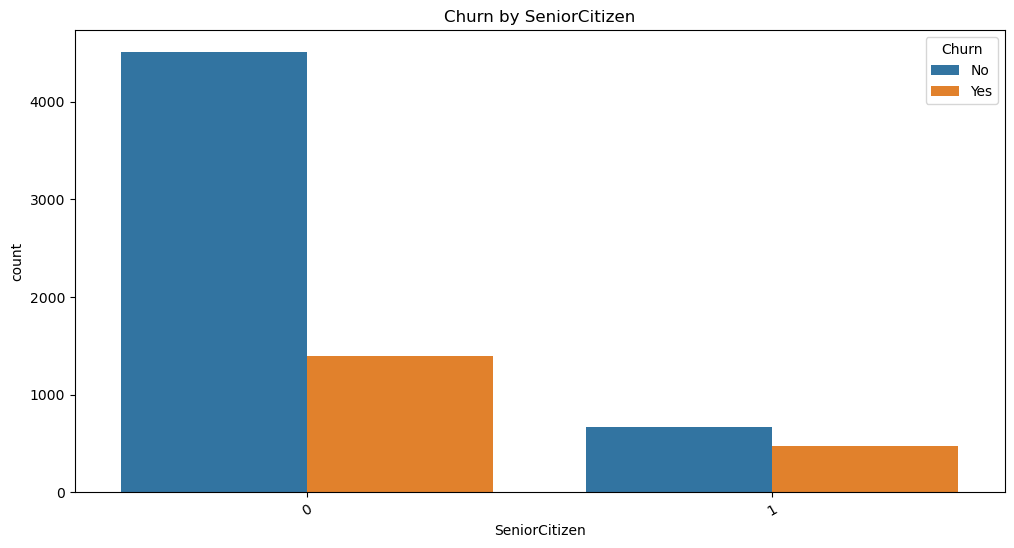

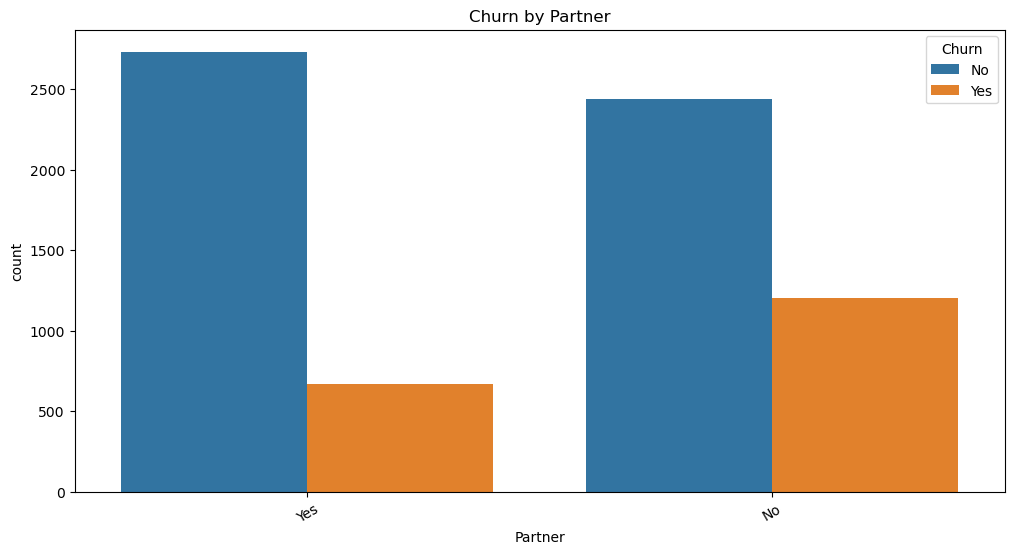

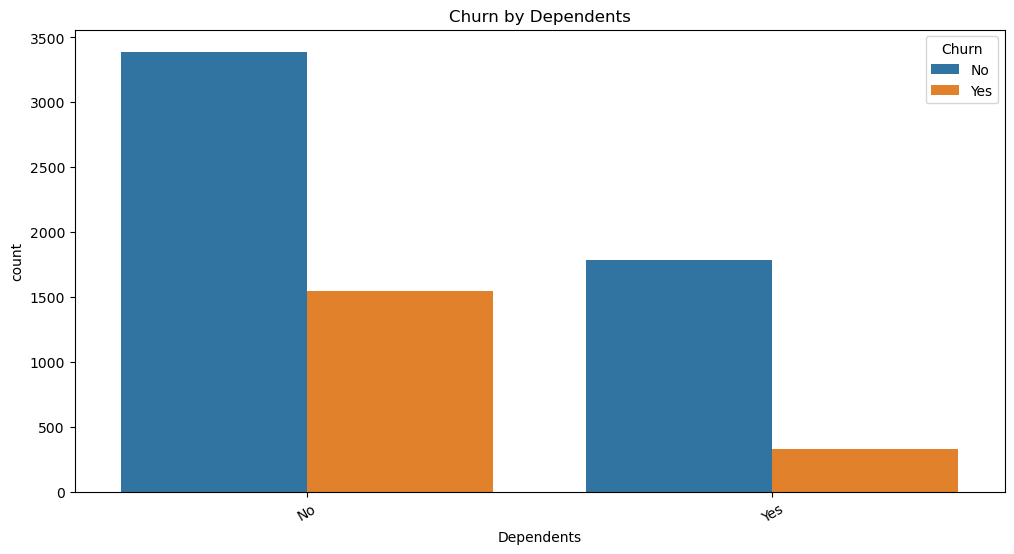

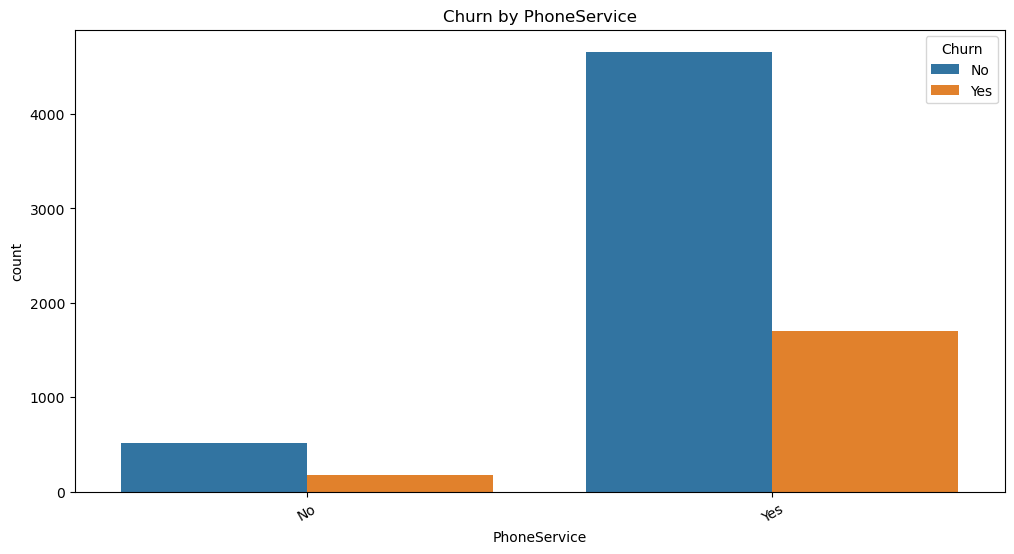

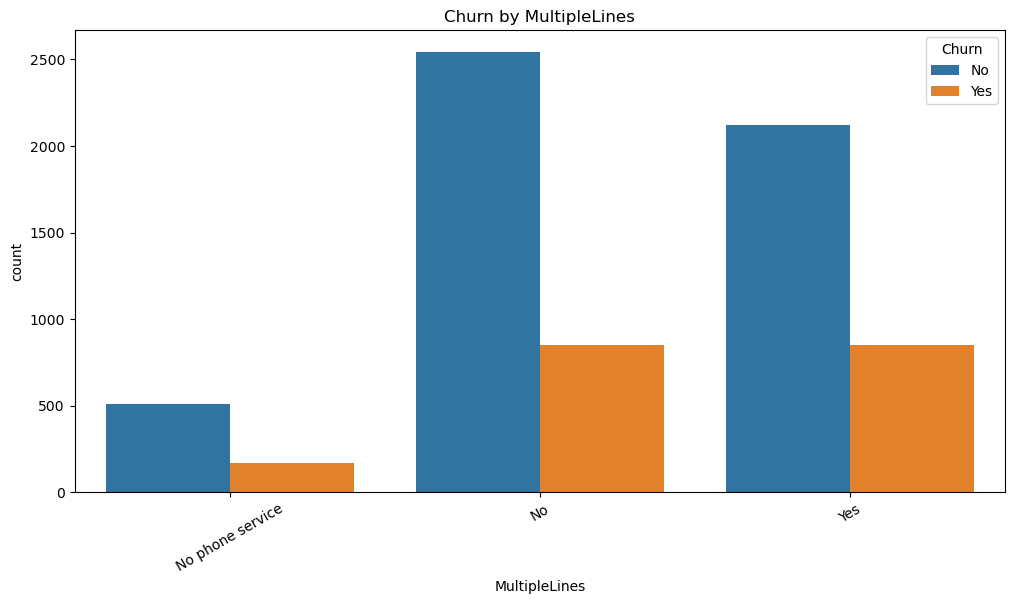

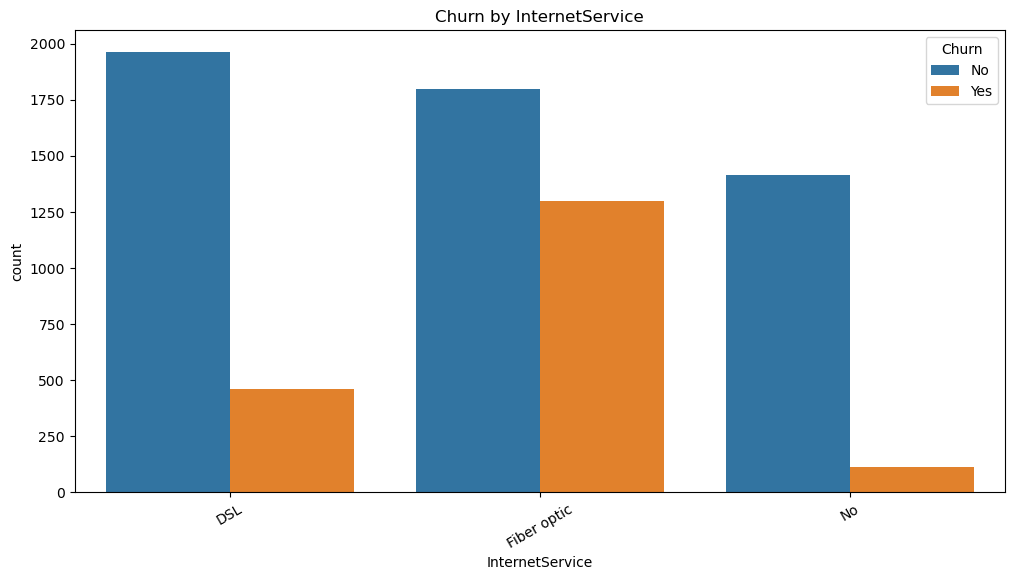

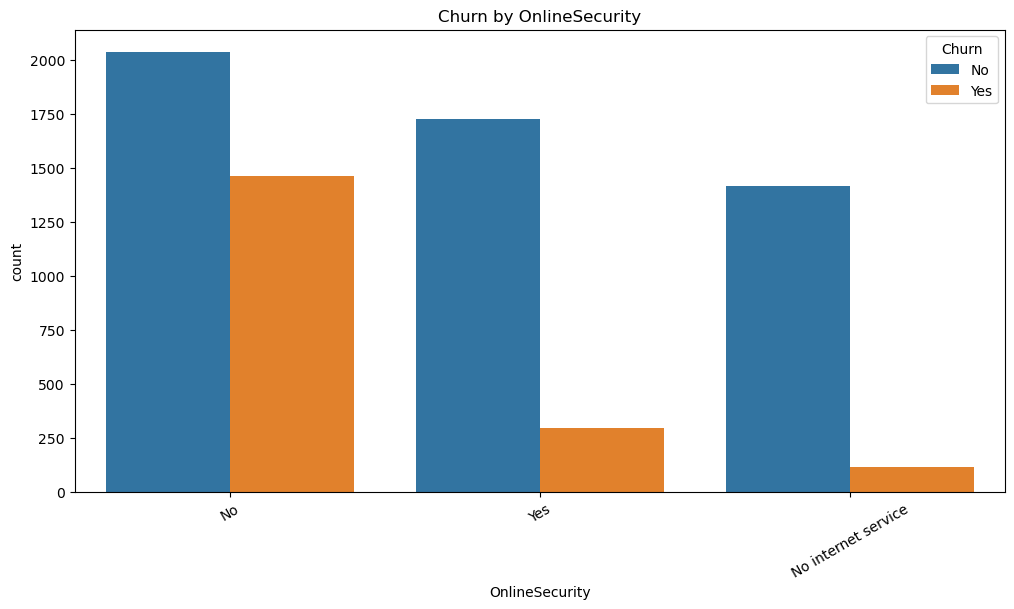

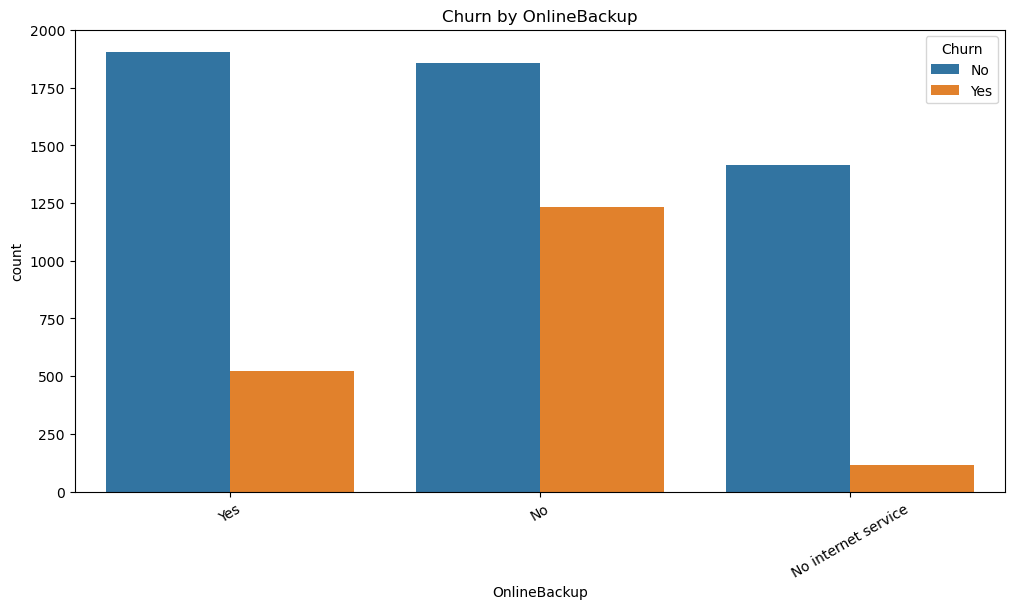

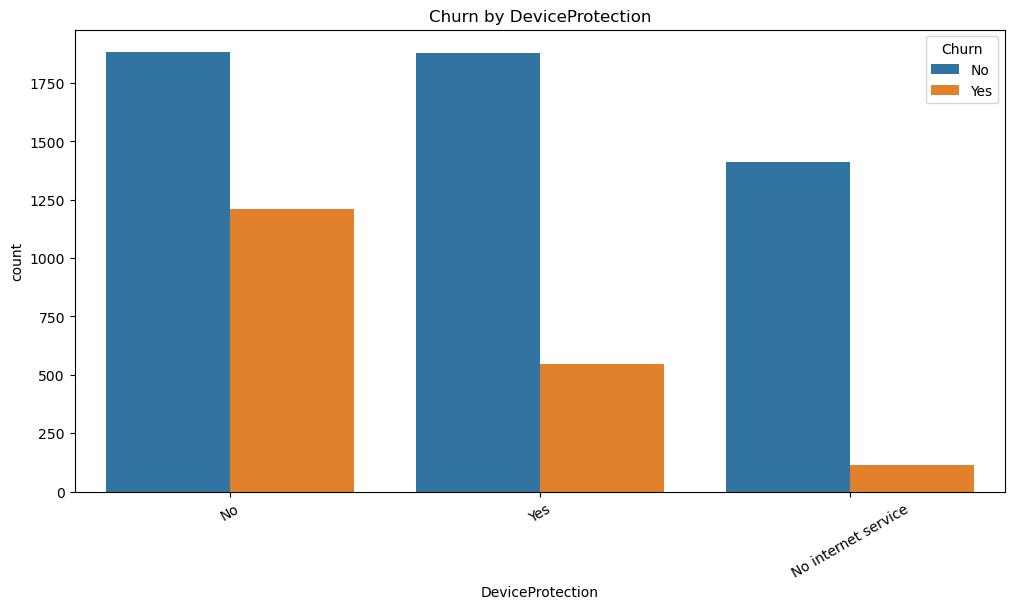

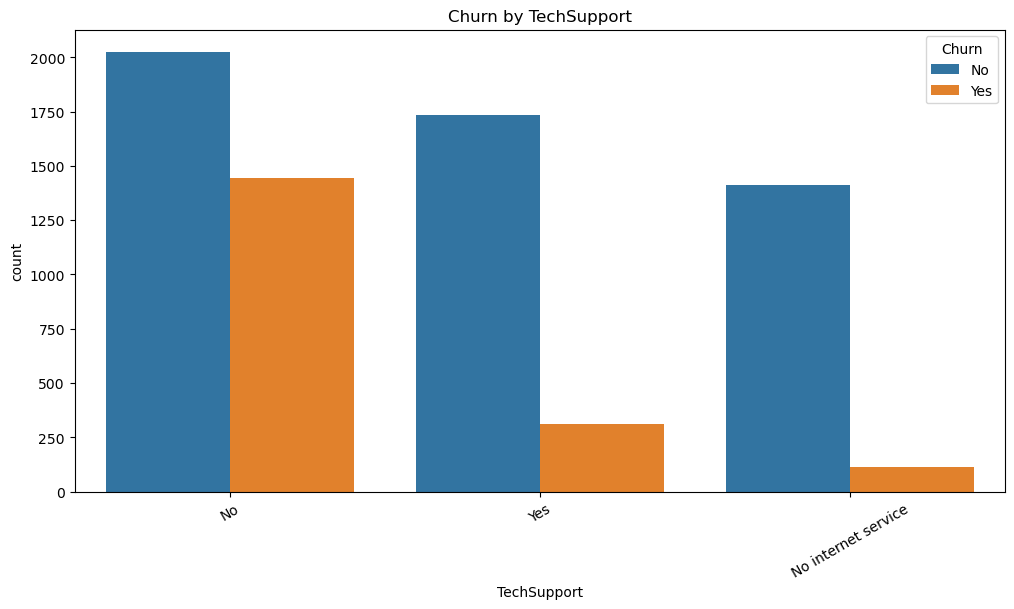

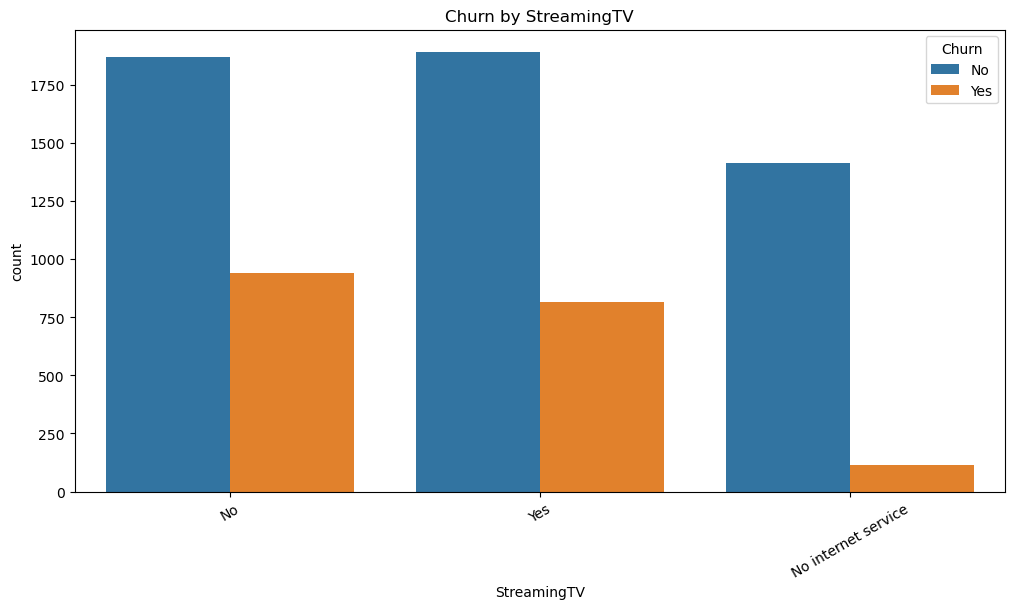

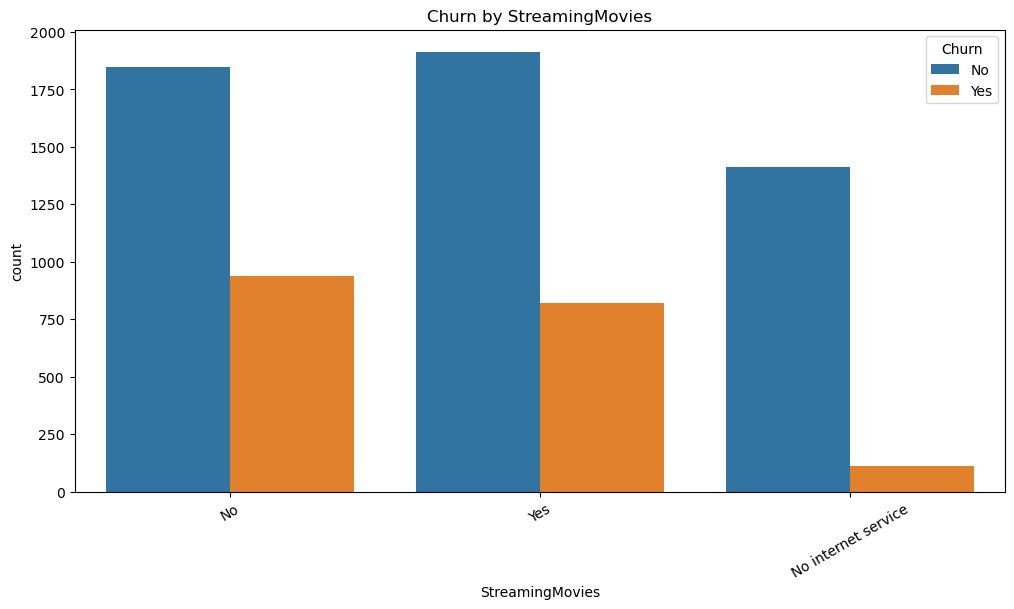

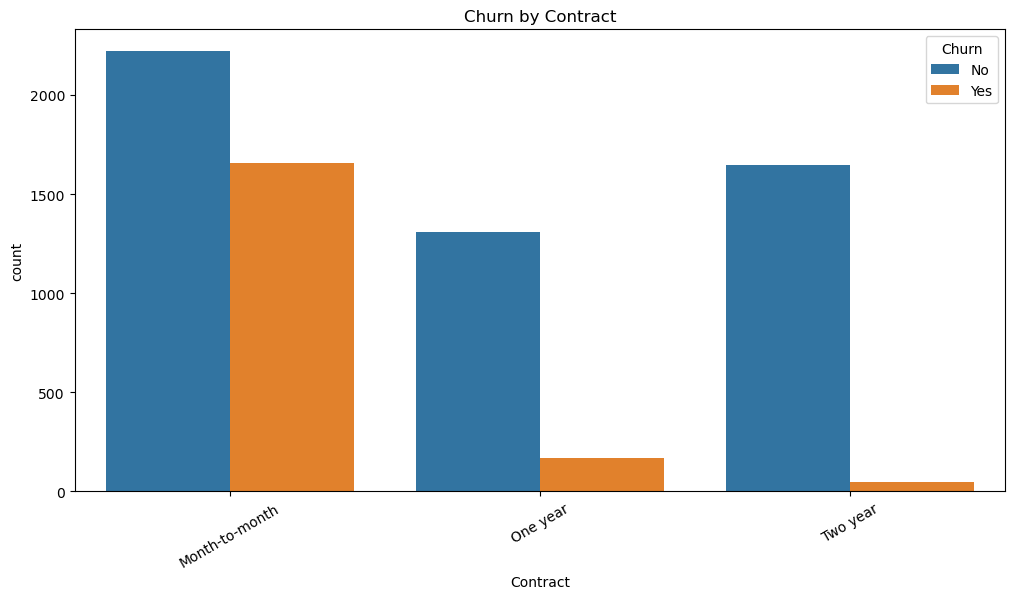

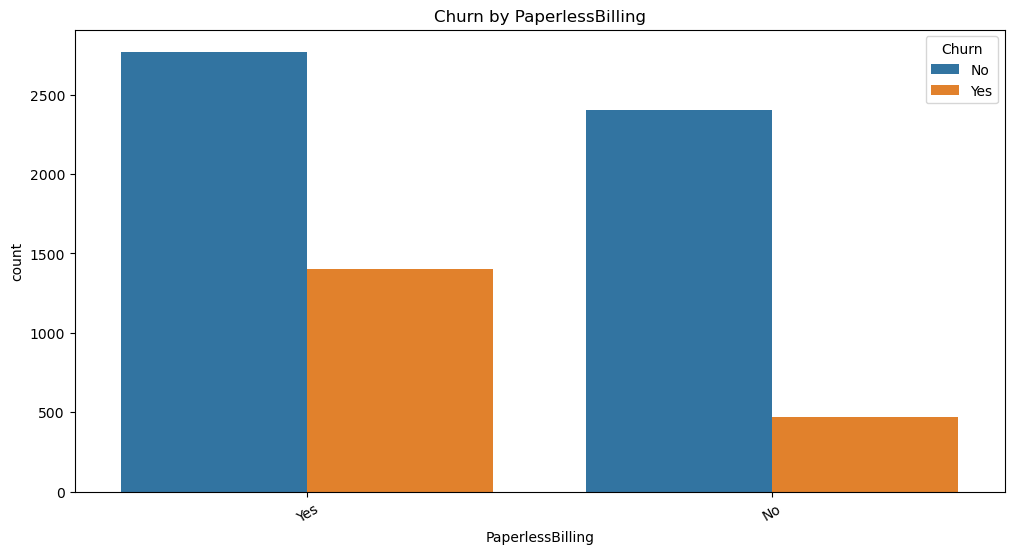

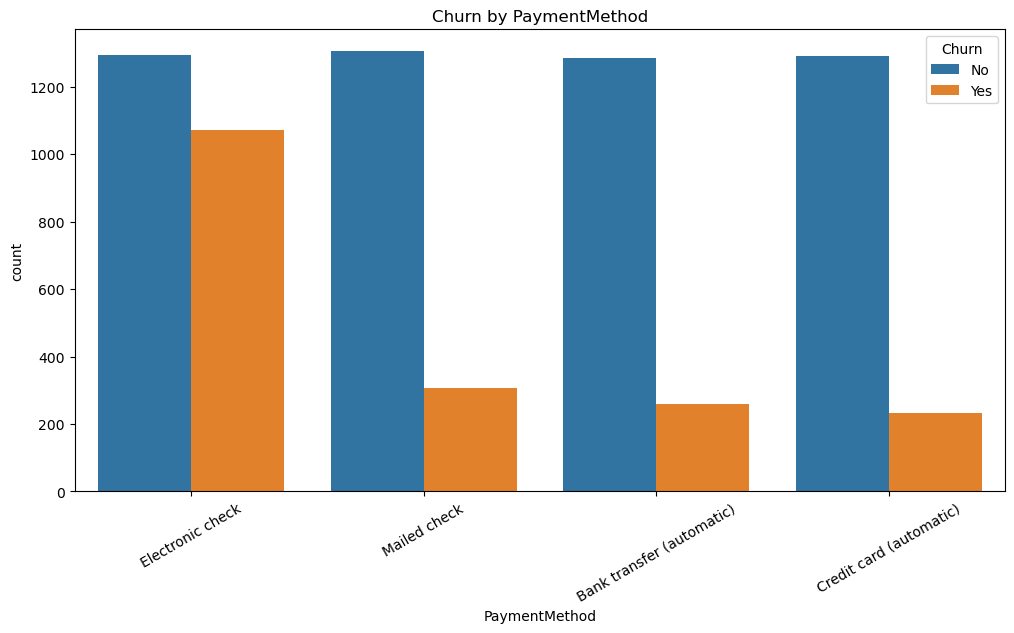

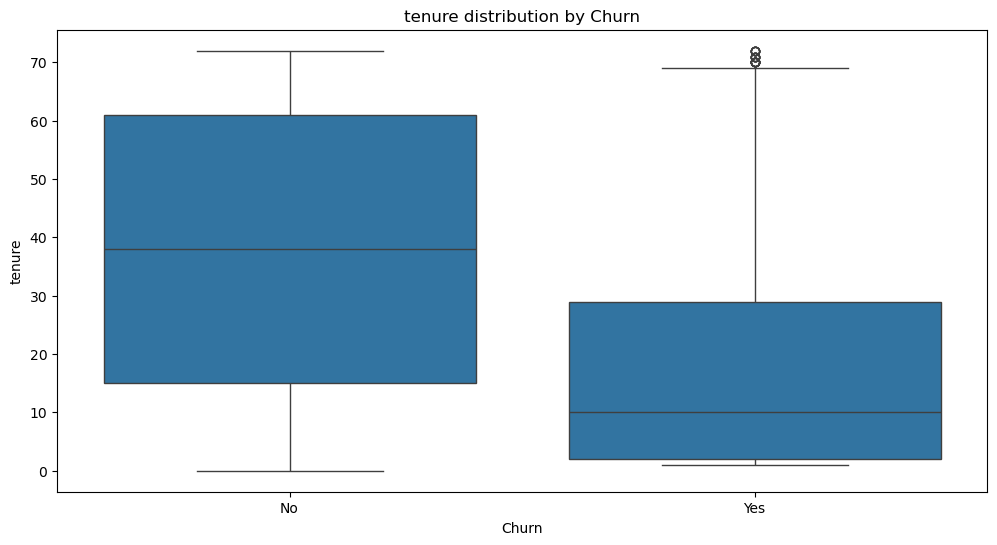

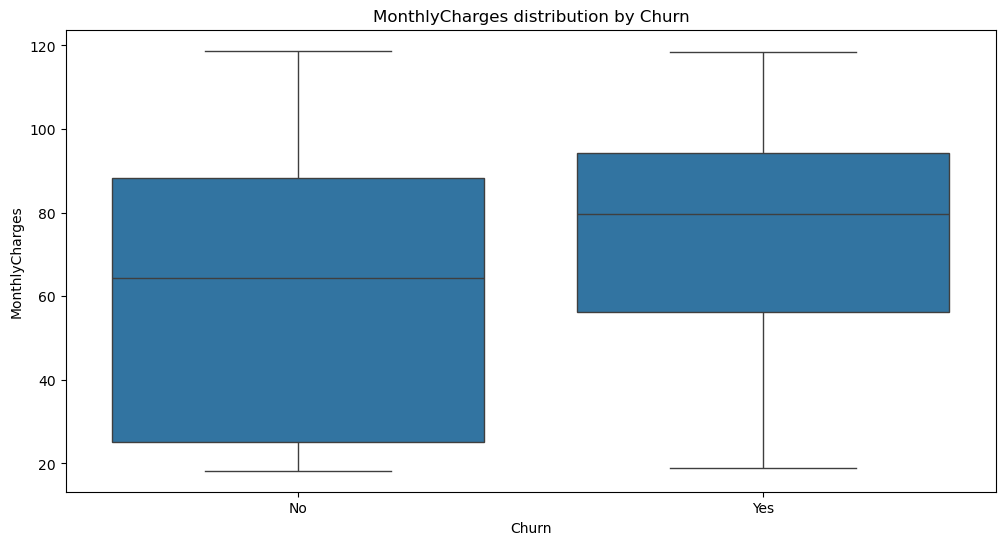

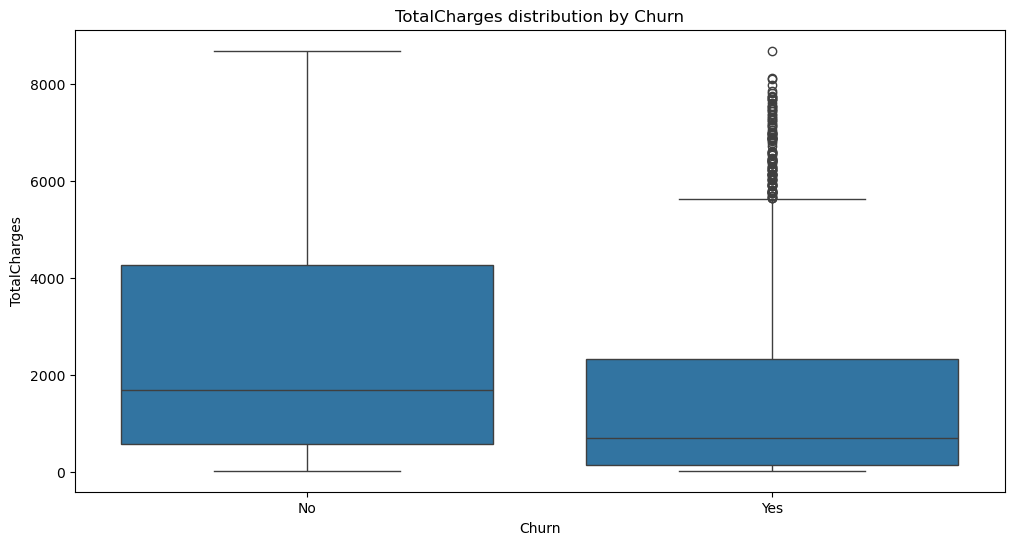

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------- Categorical Features ---------
categorical_feature = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Countplots for categorical features
for i, feature in enumerate(categorical_feature): 
    plt.figure(i, figsize=(12,6))
    sns.countplot(data=df, x=feature, hue='Churn')
    plt.title(f"Churn by {feature}")
    plt.xticks(rotation=30)
    plt.show()

# --------- Numerical Features ---------
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Boxplots for numerical features
for i, feature in enumerate(numerical_features): 
    plt.figure(i, figsize=(12,6))
    sns.boxplot(data=df, x='Churn', y=feature)
    plt.title(f"{feature} distribution by Churn")
    plt.show()